<a href="https://colab.research.google.com/github/Zuhair0000/Pytorch-Bootcamp/blob/main/01_pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

In [2]:
torch.__version__

'2.10.0+cu128'

In [3]:
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X * bias

X[:10], y[:10], len(X), len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.0000],
         [0.0042],
         [0.0084],
         [0.0126],
         [0.0168],
         [0.0210],
         [0.0252],
         [0.0294],
         [0.0336],
         [0.0378]]),
 50,
 50)

In [4]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [5]:
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [6]:
def plot_preditions(train_data = X_train,
                    train_labels = y_train,
                    test_data = X_test,
                    test_labels = y_test,
                    predictions=None):

  plt.figure(figsize=(10, 7))

  plt.scatter(train_data, train_labels, c='b', s=4, label='Training data')

  plt.scatter(test_data, test_labels, c='g', s=4, label='Testing data')

  if predictions is not None:
    plt.scatter(test_data, predictions, c='r', s=4, label='Predictions')

  plt.legend(prop={'size':14})

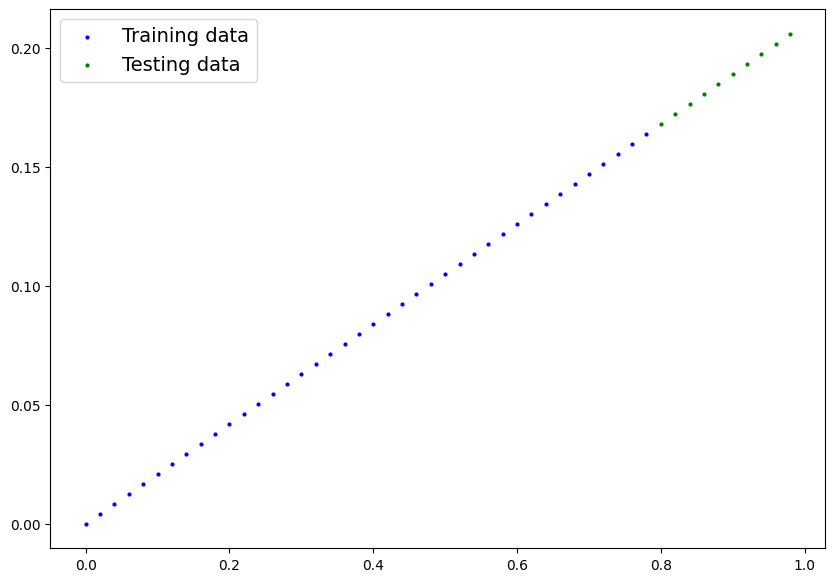

In [7]:
plot_preditions()

# Build model

### Linear Regression

In [8]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad=True,
                                            dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True,
                                         dtype=float))

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias

In [35]:
torch.manual_seed(42)

model_0 = LinearRegressionModel()
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], dtype=torch.float64, requires_grad=True)]

In [36]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])),
             ('bias', tensor([0.1288], dtype=torch.float64))])

In [37]:
y_test

tensor([[0.1680],
        [0.1722],
        [0.1764],
        [0.1806],
        [0.1848],
        [0.1890],
        [0.1932],
        [0.1974],
        [0.2016],
        [0.2058]])

## Model predictions using torch.inference_model()

In [38]:
with torch.inference_mode():
  y_preds = model_0(X_test)


# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], dtype=torch.float64)

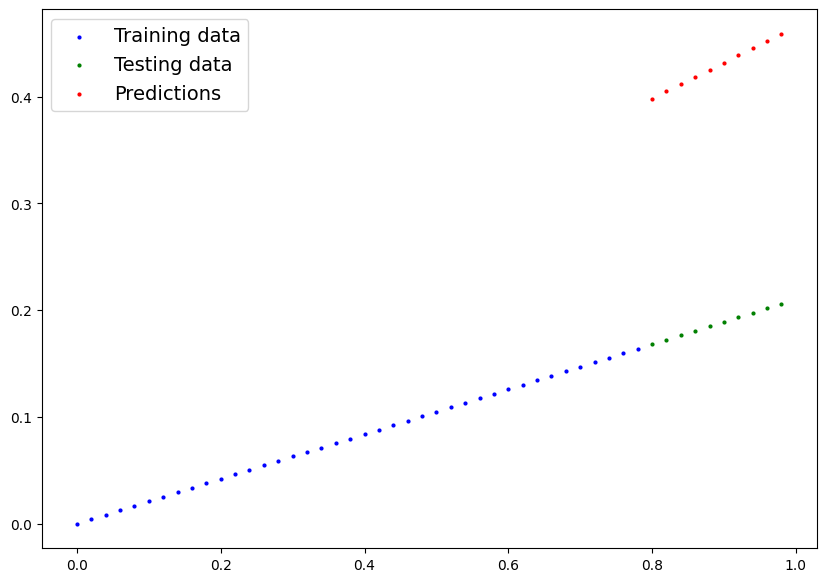

In [39]:
plot_preditions(predictions=y_preds)

## Set up a loss function and optimizer

In [40]:
# Loss function
loss_fn = nn.L1Loss()

# Optimizer
optimizer = torch.optim.SGD(model_0.parameters(),
                            lr= 0.01)

# Buiding a training loop

In [41]:
epochs = 200

epoch_count = []
loss_values = []
test_loss_values = []

for epoch in range(epochs):
  model_0.train()

  y_pred = model_0(X_train)

  loss = loss_fn(y_pred, y_train)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_0.eval()
  with torch.inference_mode():
    test_pred = model_0(X_test)

    test_loss = loss_fn(test_pred, y_test)

  if epoch % 10 == 0:
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)
    print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")

    print(model_0.state_dict())

Epoch: 0 | Loss: 0.17821864613305477 | Test loss: 0.22809283303070518
OrderedDict({'weights': tensor([0.3328]), 'bias': tensor([0.1188], dtype=torch.float64)})
Epoch: 10 | Loss: 0.06300867762855888 | Test loss: 0.09338291006136391
OrderedDict({'weights': tensor([0.2938]), 'bias': tensor([0.0188], dtype=torch.float64)})
Epoch: 20 | Loss: 0.011290014354897807 | Test loss: 0.025797019231800732
OrderedDict({'weights': tensor([0.2645]), 'bias': tensor([-0.0227], dtype=torch.float64)})
Epoch: 30 | Loss: 0.007851205969242523 | Test loss: 0.017524582195763295
OrderedDict({'weights': tensor([0.2473]), 'bias': tensor([-0.0157], dtype=torch.float64)})
Epoch: 40 | Loss: 0.004412406745473068 | Test loss: 0.00925218390274496
OrderedDict({'weights': tensor([0.2302]), 'bias': tensor([-0.0087], dtype=torch.float64)})
Epoch: 50 | Loss: 0.009151073981278412 | Test loss: 0.0006052837853476545
OrderedDict({'weights': tensor([0.2160]), 'bias': tensor([-0.0047], dtype=torch.float64)})
Epoch: 60 | Loss: 0.009

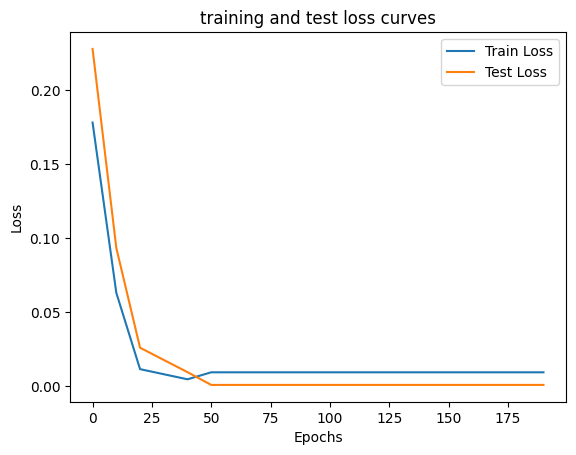

In [49]:
import numpy as np

plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label='Train Loss')
plt.plot(epoch_count, test_loss_values, label='Test Loss')
plt.title('training and test loss curves')
plt.ylabel('Loss')
plt.xlabel("Epochs")
plt.legend()

In [42]:
weight, bias

(0.7, 0.3)

In [43]:
with torch.inference_mode():
  y_preds_new = model_0(X_test)

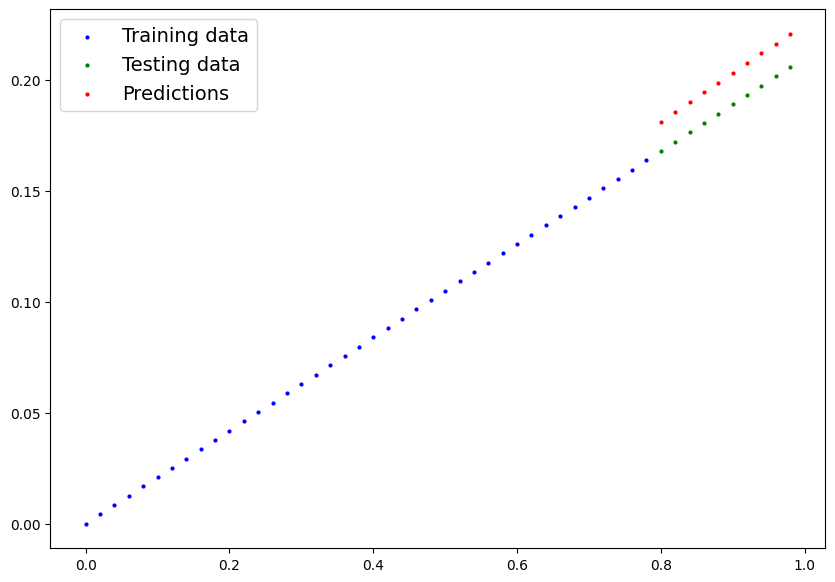

In [44]:
plot_preditions(predictions=y_preds_new)

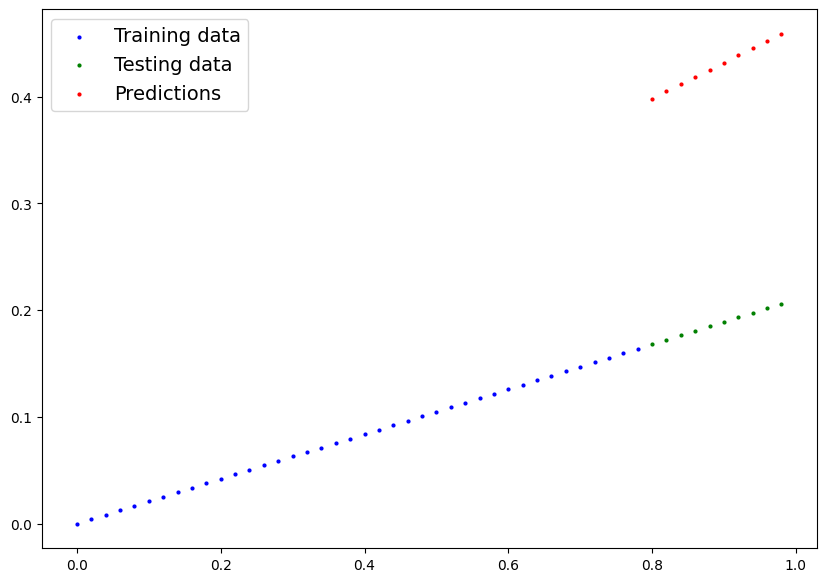

In [45]:
plot_preditions(predictions=y_preds)

In [46]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.2199])),
             ('bias', tensor([0.0053], dtype=torch.float64))])

# Saving a model in PyTorch

In [50]:
from pathlib import Path

MODEL_PATH = Path('model')
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = '01_pytorch_workflow_model_0.pth'
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saveing model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),
           f=MODEL_SAVE_PATH)

Saveing model to: model/01_pytorch_workflow_model_0.pth
